# 01 — Data Quality & EDA

**Part 1 (step 1.3): data quality.** Part 2 (EDA, step 1.5) is added later.

Findings and decisions are written up in [`docs/data_quality.md`](../docs/data_quality.md).
Only aggregate statistics are shown here; no individual lead rows are printed (dataset license: unknown).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from apex.config import load_config, path
from apex.data.clean import clean
from apex.data.load import describe_raw, load_raw

pd.set_option("display.max_rows", 60, "display.width", 160)
cfg = load_config()["data"]
FIG_DIR = path("figures_dir")
FIG_DIR.mkdir(parents=True, exist_ok=True)

raw = load_raw()
info = describe_raw()
{k: v for k, v in info.items() if k != "columns"}

{'file': 'Leads.csv',
 'sha256': '1426dffd94246b8c7f08d1080d9c04115a0c4b67eadcba1ed9d2fa10d3762802',
 'size_mb': 2.37,
 'n_rows': 9240,
 'n_columns': 37,
 'target_rate': 0.3854}

## 1. Missing values, including the hidden `"Select"` placeholder

In [2]:
text = raw.astype("string")
placeholder = text.isin(cfg["missing_placeholders"])
missing = pd.DataFrame({
    "nan_%": raw.isna().mean() * 100,
    "placeholder_%": placeholder.mean() * 100,
})
missing["total_%"] = missing.sum(axis=1)
missing = missing[missing["total_%"] > 0].sort_values("total_%", ascending=False).round(1)
missing

,nan_%,placeholder_%,total_%
How did you hear about X Education,23.9,54.6,78.5
Lead Profile,29.3,44.9,74.2
Lead Quality,51.6,0.0,51.6
Asymmetrique Activity Index,45.6,0.0,45.6
Asymmetrique Profile Index,45.6,0.0,45.6
Asymmetrique Profile Score,45.6,0.0,45.6
Asymmetrique Activity Score,45.6,0.0,45.6
City,15.4,24.3,39.7
Specialization,15.6,21.0,36.6
Tags,36.3,0.0,36.3


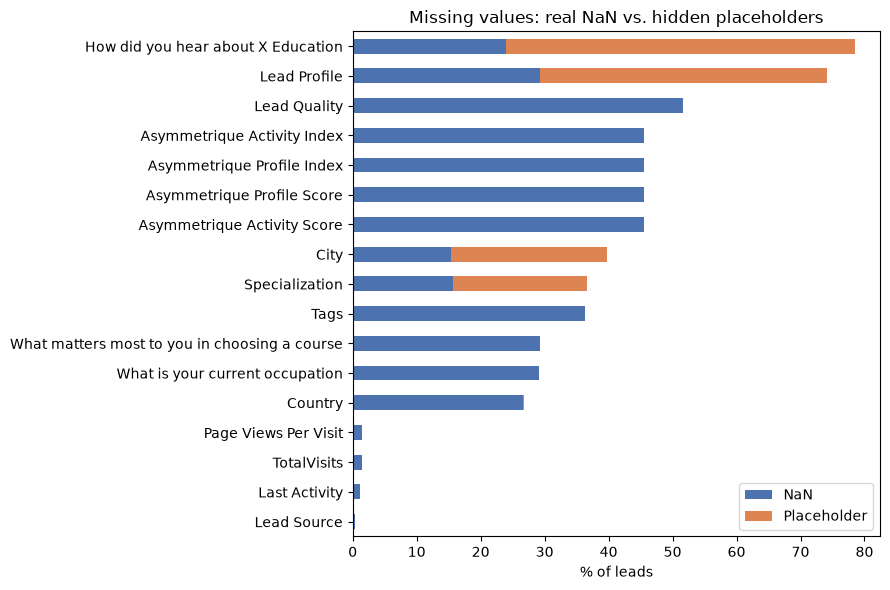

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
missing[["nan_%", "placeholder_%"]].iloc[::-1].plot.barh(stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xlabel("% of leads")
ax.set_title("Missing values: real NaN vs. hidden placeholders")
ax.legend(["NaN", "Placeholder"], loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "dq_missing_values.png", dpi=120)

### Is missingness related to conversion?

In [4]:
is_missing = raw.isna() | placeholder
rows = []
for col in missing.index:
    m = is_missing[col]
    rows.append({
        "column": col,
        "missing_%": round(m.mean() * 100, 1),
        "conv_when_missing_%": round(raw.loc[m, cfg["target"]].mean() * 100, 1),
        "conv_when_present_%": round(raw.loc[~m, cfg["target"]].mean() * 100, 1),
    })
print(f"overall conversion: {raw[cfg['target']].mean():.1%}")
pd.DataFrame(rows).set_index("column")

overall conversion: 38.5%


,missing_%,conv_when_missing_%,conv_when_present_%
column,,,
How did you hear about X Education,78.5,37.4,42.6
Lead Profile,74.2,30.1,62.9
Lead Quality,51.6,21.5,56.7
Asymmetrique Activity Index,45.6,39.2,38.0
Asymmetrique Profile Index,45.6,39.2,38.0
Asymmetrique Profile Score,45.6,39.2,38.0
Asymmetrique Activity Score,45.6,39.2,38.0
City,39.7,34.3,41.4
Specialization,36.6,28.7,44.2


## 2. Constant and near-constant columns

In [5]:
top_share = raw.apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
near_constant = top_share[top_share >= 0.998].sort_values(ascending=False)
pd.DataFrame({
    "top_value_share": near_constant.round(4),
    "minority_count": [int((1 - s) * len(raw) + 0.5) for s in near_constant],
    "in_drop_columns": [c in cfg["drop_columns"] for c in near_constant.index],
})

,top_value_share,minority_count,in_drop_columns
Magazine,1.0000,0,True
Update me on Supply Chain Content,1.0000,0,True
Get updates on DM Content,1.0000,0,True
I agree to pay the amount through cheque,1.0000,0,True
Receive More Updates About Our Courses,1.0000,0,True
Newspaper,0.9999,1,True
X Education Forums,0.9999,1,True
Do Not Call,0.9998,2,True
Newspaper Article,0.9998,2,True
Digital Advertisement,0.9996,4,True


## 3. Label consistency

In [6]:
for col in ["Lead Source", "Tags"]:
    values = raw[col].dropna()
    norm = values.str.strip().str.replace(r"\s+", " ", regex=True).str.lower()
    clashes = values.groupby(norm).unique()
    clashes = clashes[clashes.str.len() > 1]
    print(col, "→ variants of the same label:", clashes.to_dict() or "none")
print("Tags with repeated spaces:", raw["Tags"].str.contains("  ", na=False).sum())

Lead Source → variants of the same label: {'google': <ArrowStringArray>
['Google', 'google']
Length: 2, dtype: str}
Tags → variants of the same label: none
Tags with repeated spaces: 117


## 4. Duplicates

In [7]:
features = raw.drop(columns=cfg["id_columns"])
groups = features.groupby(list(features.columns.drop(cfg["target"])), dropna=False)[cfg["target"]].agg(["size", "nunique"])
pd.Series({
    "duplicate Prospect ID": raw["Prospect ID"].duplicated().sum(),
    "duplicate Lead Number": raw["Lead Number"].duplicated().sum(),
    "fully duplicated rows": raw.duplicated().sum(),
    "rows identical except IDs": groups.loc[groups["size"] > 1, "size"].sum(),
    "groups of identical rows": (groups["size"] > 1).sum(),
    "groups with different outcomes": (groups["nunique"] > 1).sum(),
})

duplicate Prospect ID                0
duplicate Lead Number                0
fully duplicated rows                0
rows identical except IDs         1489
groups of identical rows           193
groups with different outcomes      15
dtype: int64

## 5. Numeric columns and outliers

In [8]:
num = cfg["numeric_columns"]
summary = raw[num].describe(percentiles=[0.5, 0.95, 0.99]).T
summary["zeros"] = (raw[num] == 0).sum()
q1, q3 = raw[num].quantile(0.25), raw[num].quantile(0.75)
summary["above_Q3+1.5IQR"] = (raw[num] > q3 + 1.5 * (q3 - q1)).sum()
summary.round(2)

,count,mean,std,min,50%,95%,99%,max,zeros,above_Q3+1.5IQR
TotalVisits,9103.0,3.45,4.85,0.0,3.0,10.0,17.00,251.0,2189,267
Total Time Spent on Website,9240.0,487.70,548.02,0.0,248.0,1562.0,1840.61,2272.0,2193,0
Page Views Per Visit,9103.0,2.36,2.16,0.0,2.0,6.0,9.00,55.0,2189,360


In [9]:
visits, time, pages = (raw[c] for c in num)
pd.Series({
    "negative values": int((raw[num] < 0).sum().sum()),
    "non-integer TotalVisits": int((visits.dropna() % 1 != 0).sum()),
    "visits = 0 but time > 0": int(((visits == 0) & (time > 0)).sum()),
    "visits = 0 but pages > 0": int(((visits == 0) & (pages > 0)).sum()),
    "visits > 0 but time = 0": int(((visits > 0) & (time == 0)).sum()),
    "visits & pages missing on same rows": bool((visits.isna() == pages.isna()).all()),
})

negative values                           0
non-integer TotalVisits                   0
visits = 0 but time > 0                   0
visits = 0 but pages > 0                  0
visits > 0 but time = 0                   4
visits & pages missing on same rows    True
dtype: object

In [10]:
print("Zero-activity leads by origin:", raw.loc[visits == 0, "Lead Origin"].value_counts().to_dict())
print("Missing-activity leads by origin:", raw.loc[visits.isna(), "Lead Origin"].value_counts().to_dict())
raw.groupby("Lead Origin")[cfg["target"]].agg(["size", "mean"]).round(3)

Zero-activity leads by origin: {'API': 1602, 'Lead Add Form': 557, 'Lead Import': 30}
Missing-activity leads by origin: {'Lead Add Form': 110, 'Lead Import': 24, 'API': 2, 'Quick Add Form': 1}


,size,mean
Lead Origin,,
API,3580,0.311
Landing Page Submission,4886,0.362
Lead Add Form,718,0.925
Lead Import,55,0.236
Quick Add Form,1,1.000


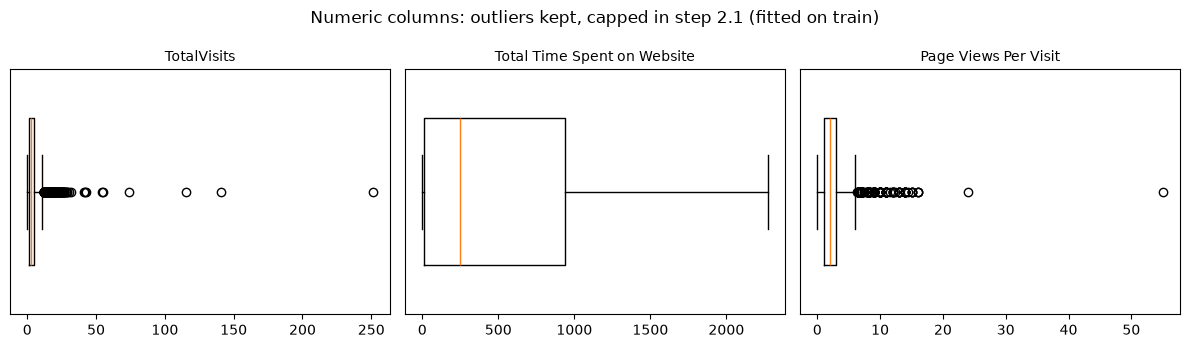

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, num):
    ax.boxplot(raw[col].dropna(), orientation="horizontal", widths=0.6)
    ax.set_title(col, fontsize=10)
    ax.set_yticks([])
fig.suptitle("Numeric columns: outliers kept, capped in step 2.1 (fitted on train)")
fig.tight_layout()
fig.savefig(FIG_DIR / "dq_numeric_outliers.png", dpi=120)

## 6. Apply the cleaning rules

In [12]:
clean_df = clean(raw)
print(f"raw: {raw.shape} → clean: {clean_df.shape}")
pd.Series({
    "rows removed": len(raw) - len(clean_df),
    "placeholders left": int(clean_df.astype("string").isin(cfg["missing_placeholders"]).sum().sum()),
    "'google' left in Lead Source": int((clean_df["Lead Source"] == "google").sum()),
    "columns dropped": raw.shape[1] - clean_df.shape[1],
})

raw: (9240, 37) → clean: (9240, 23)


rows removed                     0
placeholders left                0
'google' left in Lead Source     0
columns dropped                 14
dtype: int64

In [13]:
clean_df.dtypes.astype(str).value_counts()

str        15
float64     4
Int8        2
int64       2
Name: count, dtype: int64